In [55]:
from math import sqrt


def dist_euclidiana(p, q):
    resultado = 0

    for item in zip(p, q):
        resultado += (item[0] - item[1]) ** 2
    
    return sqrt(resultado)

In [56]:

from collections import Counter


def knn_sem_moda(treino, rotulos, teste, k):
    rotulos_finais = []

    for dado in teste:
        distancias = []
        
        for i in range(len(treino)):
            distancias.append((dist_euclidiana(treino[i], dado), rotulos[i])) 

        distancias.sort(key=lambda x: x[0])

        distancias = distancias[:k]
        votos = [tuple(x[1]) for x in distancias]

        rotulo_principal = Counter(votos).most_common(1)[0][0]

        rotulos_finais.append(rotulo_principal)

    return rotulos_finais

    

In [57]:
### grupo de dados 1 (dataset iris)

import scipy.io as scipy

mat = scipy.loadmat('grupoDados1.mat')
grupoTest = mat['grupoTest']
grupoTrain = mat['grupoTrain']
trainRots = mat['trainRots']
testRots = mat['testRots']

rotuloPrevisto = knn_sem_moda(grupoTrain, trainRots, grupoTest, 1)

estaCorreto = rotuloPrevisto == testRots

numCorreto = sum(estaCorreto)

totalNum = len(testRots)

acuracia = numCorreto / totalNum

print(acuracia)

[0.96]


In [58]:
from statistics import mode

def knn(treino, rotulos, teste, k):
    rotulos_finais = []

    for dado in teste:
        distancias = []
        
        for i in range(len(treino)):
            distancias.append((dist_euclidiana(treino[i], dado), rotulos[i])) 

        distancias.sort(key=lambda x: x[0])

        distancias = distancias[:k]
        votos = [tuple(x[1]) for x in distancias]

        rotulo_principal = mode(votos)

        rotulos_finais.append(rotulo_principal)

    return rotulos_finais

In [59]:
### grupo de dados 1 (dataset iris) - com mode

import scipy.io as scipy

mat = scipy.loadmat('grupoDados1.mat')
grupoTest = mat['grupoTest']
grupoTrain = mat['grupoTrain']
trainRots = mat['trainRots']
testRots = mat['testRots']

rotuloPrevisto = knn(grupoTrain, trainRots, grupoTest, 10)

estaCorreto = rotuloPrevisto == testRots

numCorreto = sum(estaCorreto)

totalNum = len(testRots)

acuracia = numCorreto / totalNum

print(acuracia)

[0.94]


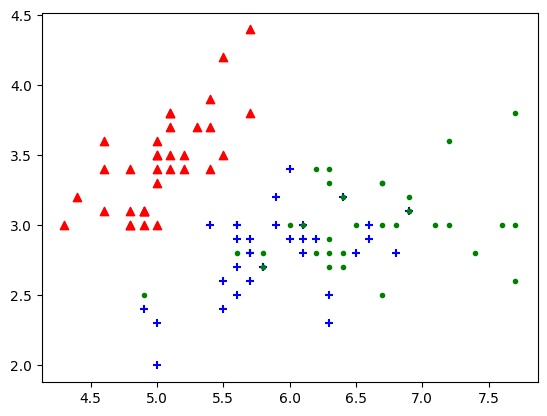

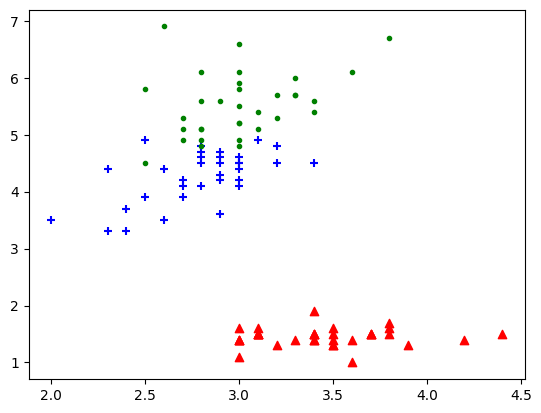

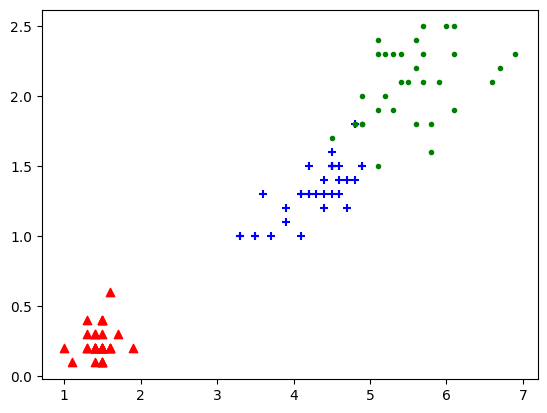

In [63]:
### grupo de dados 1 (dataset iris) - com mode - visualizacao
import matplotlib.pyplot as plt

def getDadosRotulo(dados, rotulos, rotulo, indice):
    ret = []

    for idx in range(0, len(dados)):
        if(rotulos[idx] == rotulo):
            ret.append(dados[idx][indice])        

    return ret



def visualizaPontos(dados, rotulos, d1, d2):
    fig, ax = plt.subplots() 

    ax.scatter(getDadosRotulo(dados, rotulos, 1, d1), getDadosRotulo(dados, rotulos, 1, d2), c='red' , marker='^')
    ax.scatter(getDadosRotulo(dados, rotulos, 2, d1), getDadosRotulo(dados, rotulos, 2, d2), c='blue' , marker='+')
    ax.scatter(getDadosRotulo(dados, rotulos, 3, d1), getDadosRotulo(dados, rotulos, 3, d2), c='green', marker='.')  

    plt.show()

visualizaPontos(grupoTrain, trainRots, 0, 1)
visualizaPontos(grupoTrain, trainRots, 1, 2)
visualizaPontos(grupoTrain, trainRots, 2, 3)